In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
from scipy import ndimage
import recon_plot_helpers
import matplotlib.pyplot as plt
import save_data_helpers
from ismrm_figs import mvf_utils

In [2]:
import numpy as np
import os

def extract_cost_values(base_dir, iters_to_unpack, verbose=True):
    data_fidelities = np.zeros((iters_to_unpack, 5))
    priors = np.zeros((iters_to_unpack))

    for iter in range(iters_to_unpack):

        npz_path = os.path.join(base_dir, f"iter_{iter:03d}_costs.npz")

        # Load npz file
        data = np.load(npz_path)

        # Unpack
        data_fidelity = data['data_fidelity']
        prior = data['prior']

        data_fidelities[iter, :] = data_fidelity
        priors[iter] = prior

    if verbose:
        print(f'data_fidelities.shape = {data_fidelities.shape}')

        print(f'priors = {priors}')
        
        return data_fidelities, priors


# Base directory
base_dir = "/data/lilianae/ADMM_results/sweep_20251105_163705/original_z_rho_0.01_beta_0.0001_lam_0.001/iters/"
# base_dir = '/data/lilianae/ADMM_results/admm_100sp_rho_0.01_beta_0.0001_lam1e-2_8iters/iters/'
num_iters = 8

dfs, priors = extract_cost_values(base_dir=base_dir, iters_to_unpack=num_iters)

data_fidelities.shape = (8, 5)
priors = [19124.01367188 23131.75585938 24911.9765625  25856.07226562
 26407.69726562 26745.18359375 26950.4296875  27094.06640625]


### 1. Data fidelity + prior vs. Iteration number

In [3]:
def cost_value_subplots(data_fidelity_all, prior_all, gate):
    fig, axs = plt.subplots(1, 2, figsize=(8,5))
    for i in range(8):
        axs[0].scatter(i, data_fidelity_all[i][gate])
        axs[1].scatter(i, prior_all[gate])

        axs[0].set_xlabel("Iter #")
        axs[0].set_ylabel("Data fidelity value")
        axs[0].set_title(f"Gate {gate}: Data fidelity vs iter #")

        axs[1].set_xlabel("Iter #")
        axs[1].set_ylabel("Prior value")
        axs[1].set_title(f"Gate {gate}: Prior vs iter #")

    plt.show()

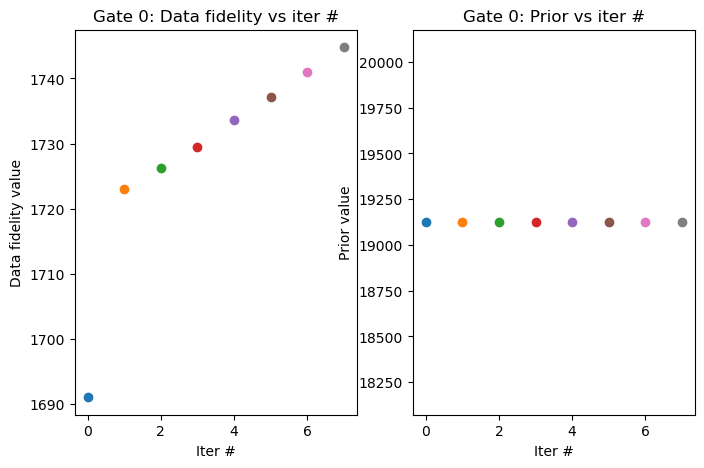

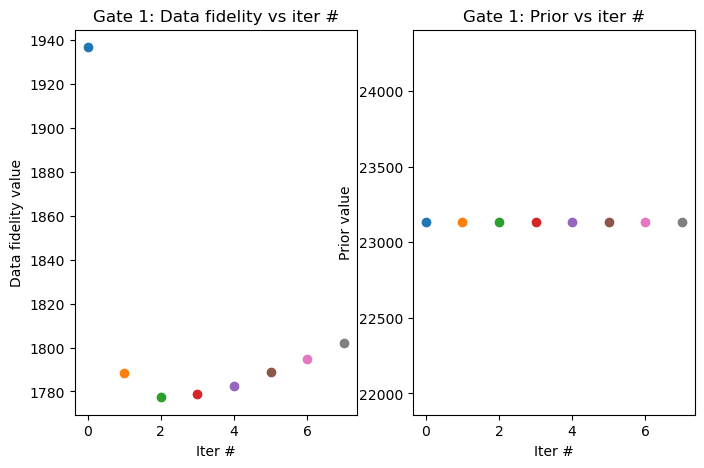

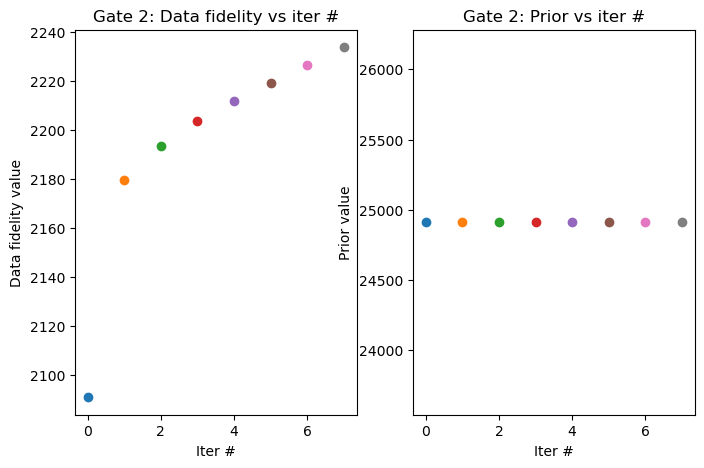

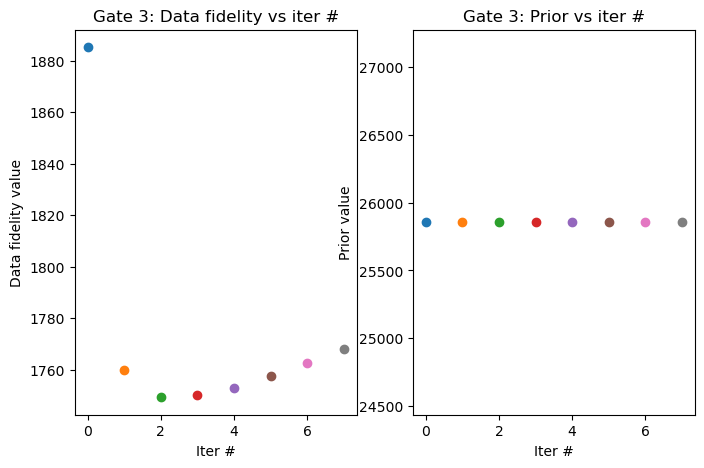

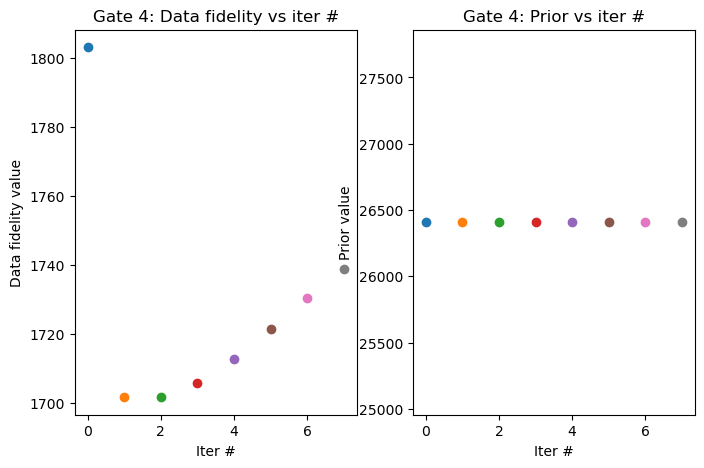

In [4]:
for gate in range(5):
    cost_value_subplots(dfs, priors, gate)

### 2. L2 Norm of S_k over iterations

In [5]:
def admm_outputs_all_iters(base_dir, num_iters, gate_idx):
    '''Get ADMM outputs for one gate across all iterations'''
    z_all = [None] * num_iters
    lam_all = [None] * num_iters
    tmp_all = [None] * num_iters
    tmp_inv_all = [None] * num_iters

    for i in range(num_iters):
        z_abs, lam_abs, tmp_admm, tmp_inv_admm = mvf_utils.load_admm_output(base_dir, i, verbose=False) 
        z_all[i] = z_abs[gate_idx]
        lam_all[i] = lam_abs
        tmp_all[i] = tmp_admm[gate_idx]
        tmp_inv_all[i] = tmp_inv_admm[gate_idx]

    return z_all, lam_all, tmp_all, tmp_inv_all

In [6]:
base_dir_admm ='/data/lilianae/ADMM_results/sweep_20251105_163705/original_z_rho_0.01_beta_0.0001_lam_0.001/'
num_iters = 8
gate_idx = 3
z_all, lam_all, tmp_all, tmp_inv_all = admm_outputs_all_iters(base_dir_admm, num_iters, gate_idx=gate_idx)


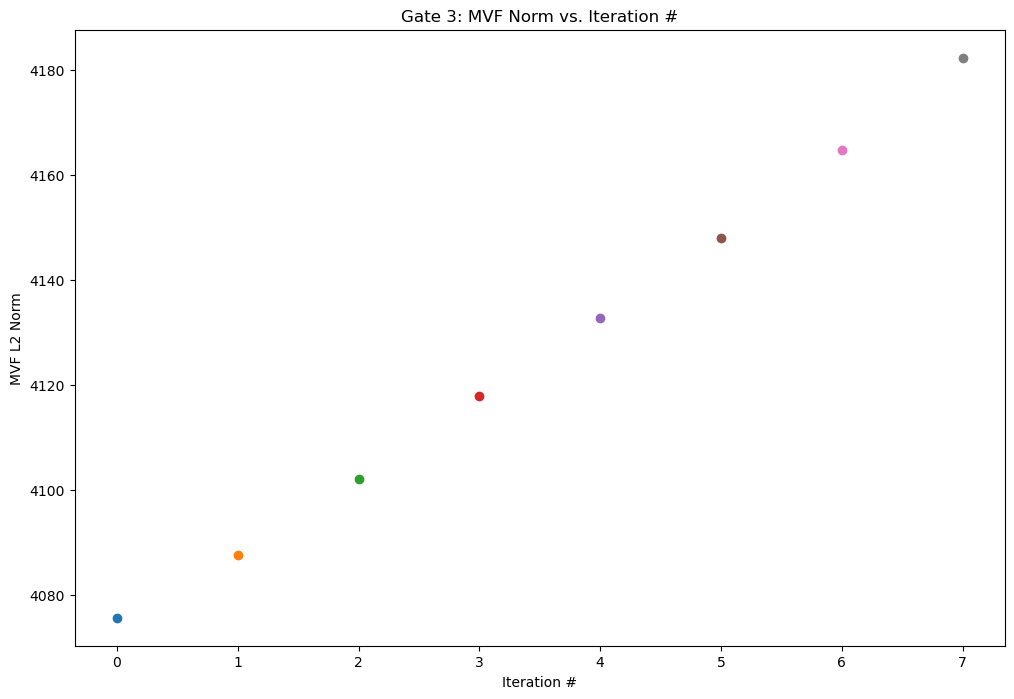

In [7]:
def plot_l2_mvf(mvf_all, gate_idx):
    '''Calculate L2 norm of MVF at each iteration'''
    plt.figure(figsize=(12, 8))
    num_iters = len(mvf_all)
    for i in range(num_iters):
        mvf_flat = mvf_all[i].ravel()
        mvf_flat_norm = np.linalg.norm(mvf_flat)
        plt.scatter(i, mvf_flat_norm)
    plt.xlabel('Iteration #')
    plt.ylabel('MVF L2 Norm')
    plt.title(f'Gate {gate_idx}: MVF Norm vs. Iteration #')
    plt.show()

plot_l2_mvf(tmp_inv_all, gate_idx)

### 3. Create operators for all motion fields

In [ ]:
def mvfs_to_operators(tmp_all, tmp_inv_all):
    '''Convert '''